# Task 1 — Maternal Risk Classifier: EDA, Model Selection & Evaluation

Predicts a mother's risk level (`low risk` / `mid risk` / `high risk`) from six routine clinical measurements, using the [UCI Maternal Health Risk](https://archive.ics.uci.edu/dataset/863/maternal+health+risk) dataset.

This notebook is the full modelling narrative for Task 1: EDA, a justified choice of algorithm (compared against alternatives, not assumed), hyperparameter tuning, and evaluation with an eye on the class that matters most operationally (`high risk`). It imports `load_data` / `split_data` / `train` directly from `src/task1_risk_classifier.py` so there is one source of truth for data loading and the train/test split — this notebook adds analysis on top, it doesn't re-implement it.

**Before running:** from the `project7-maternal-child-health/` directory, run `python scripts/download_data.py` once to populate `data/raw/maternal_health_risk.csv` (not committed to the repo).

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from task1_risk_classifier import FEATURES, TARGET, load_data, split_data, train  # noqa: E402

sns.set_theme(style="whitegrid")
RISK_ORDER = ["low risk", "mid risk", "high risk"]
RNG = 42

## 1. Load data

In [2]:
df = load_data()
print(f"Shape: {df.shape}")
df.head()

Shape: (1014, 7)


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


## 2. Data quality checks

Check for missing values and duplicate rows before trusting any downstream stats — the UCI Maternal Health Risk dataset is known to contain duplicate readings.

In [3]:
print("Missing values per column:")
print(df.isna().sum())
print()
n_dupes = df.duplicated().sum()
print(f"Duplicate rows: {n_dupes} of {len(df)} ({n_dupes / len(df):.1%})")
print()
df.describe()

Missing values per column:
Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

Duplicate rows: 562 of 1014 (55.4%)



,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


No missing values. There are duplicate rows, which is plausible for this dataset (coarse/rounded IoT vital-sign readings collapse to the same combination across different patients) — they are left in for training since the source distinguishes neither timestamp nor patient ID, but this is worth flagging as a data-quality caveat rather than silently dropping rows.

## 3. Target class distribution

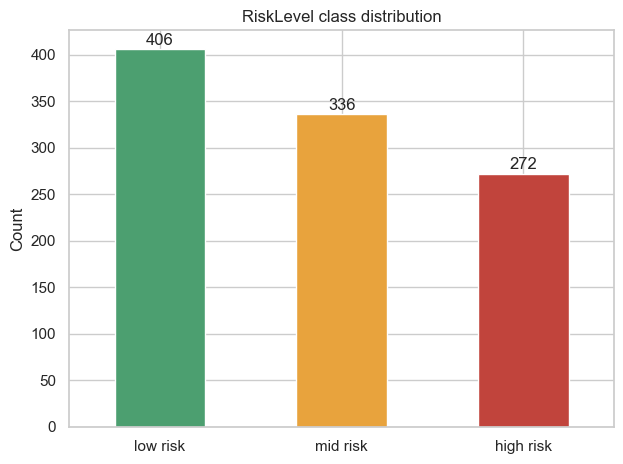

RiskLevel
low risk     0.400394
mid risk     0.331361
high risk    0.268245
Name: count, dtype: float64

In [4]:
counts = df[TARGET].value_counts().reindex(RISK_ORDER)
ax = counts.plot(kind="bar", color=["#4C9F70", "#E8A33D", "#C1443C"])
ax.set_title("RiskLevel class distribution")
ax.set_xlabel("")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
for i, v in enumerate(counts):
    ax.text(i, v + 5, str(v), ha="center")
plt.tight_layout()
plt.show()

counts / counts.sum()

Classes are moderately imbalanced (`high risk` is the smallest at ~27%) but not severely so — no resampling is applied, but this imbalance is exactly why the train/test split strategy (Section 6) and per-class recall (Section 9) matter more here than plain accuracy.

## 4. Feature distributions by risk level

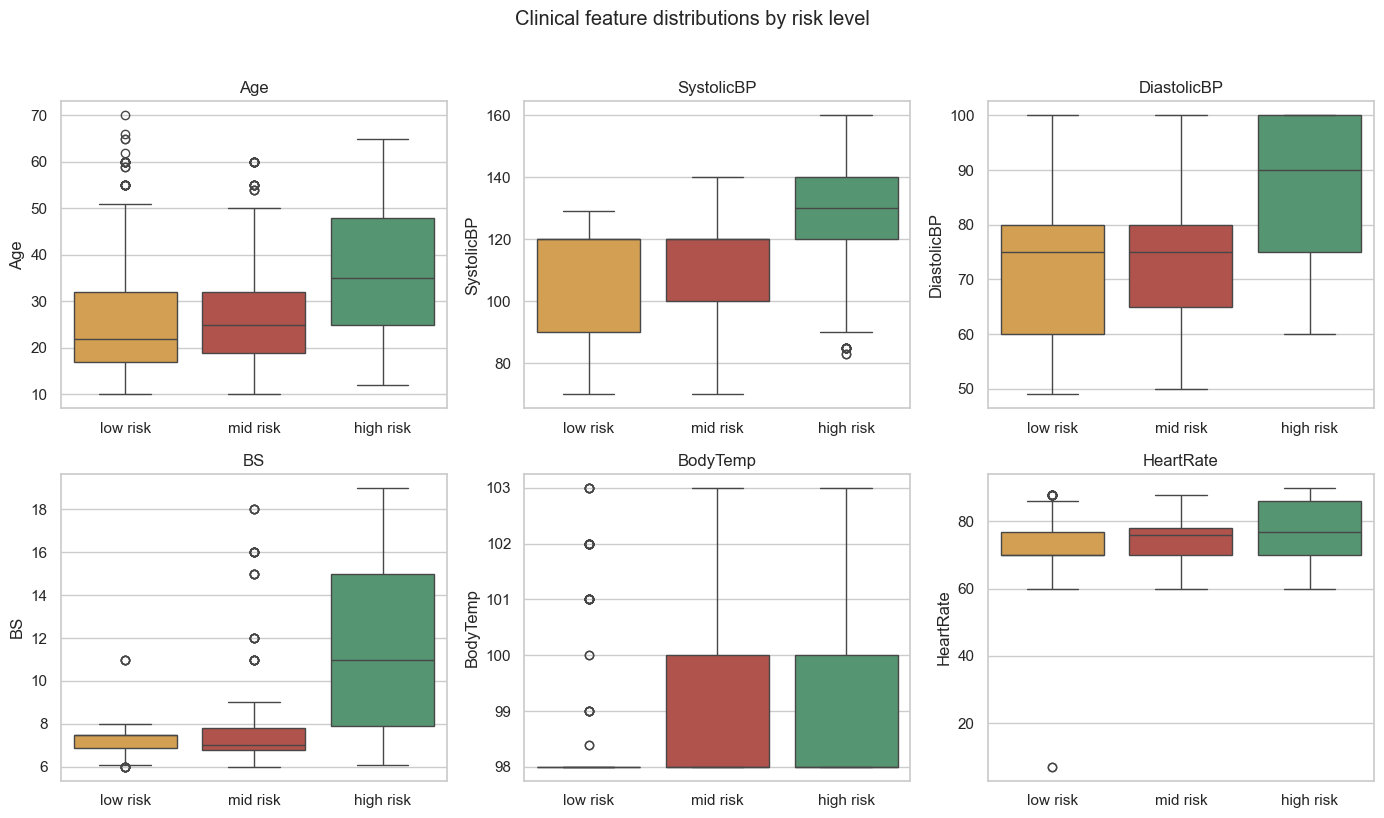

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feature in zip(axes.ravel(), FEATURES):
    sns.boxplot(data=df, x=TARGET, y=feature, order=RISK_ORDER, ax=ax, hue=TARGET,
                palette=["#4C9F70", "#E8A33D", "#C1443C"], legend=False)
    ax.set_title(feature)
    ax.set_xlabel("")
fig.suptitle("Clinical feature distributions by risk level", y=1.02)
plt.tight_layout()
plt.show()

Blood sugar (`BS`) and blood pressure (`SystolicBP`, `DiastolicBP`) show the clearest separation across risk levels, which is clinically expected — these are the features a model should lean on most. `BodyTemp` and `HeartRate` show far more overlap between classes, so they should contribute less. This is a useful prior to check the model against in Section 10 (feature importance).

## 5. Feature correlation

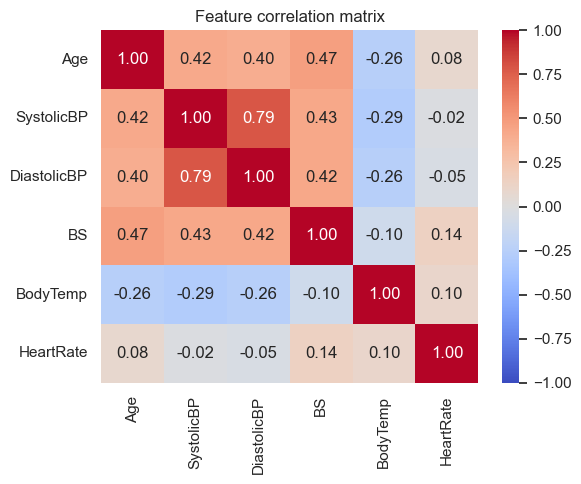

In [6]:
corr = df[FEATURES].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()

`SystolicBP` and `DiastolicBP` are strongly correlated with each other (as expected physiologically), but no pair is so collinear that it would break a model. This does, however, matter for *which* model to pick — see Section 7: linear models degrade more gracefully than tree ensembles when features are redundant, but neither breaks here.

## 6. Why a stratified train/test split?

`RiskLevel` is imbalanced (Section 3: ~40/33/27%). `train_test_split(..., stratify=y)` forces the train and test sets to preserve that same ratio. Without it, a single unlucky random split could under-represent `high risk` in the test set — the class where a missed detection is most costly — and make its recall estimate unreliable. The cell below demonstrates this directly: it draws 20 random 80/20 splits *without* stratification and compares the spread of the `high risk` test-set share against the single stratified split actually used for training.

Population 'high risk' share:            26.8%
Stratified split (random_state=42) share: 27.1%
20x unstratified splits: mean 27.6%, min 23.2%, max 31.5%


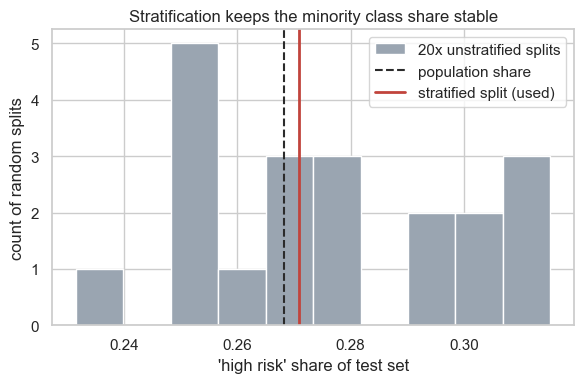

In [7]:
X, y = df[FEATURES], df[TARGET]

unstratified_shares = []
for seed in range(20):
    _, X_te, _, y_te = train_test_split(X, y, test_size=0.2, random_state=seed)
    unstratified_shares.append((y_te == "high risk").mean())

_, X_te_strat, _, y_te_strat = split_data(df)
stratified_share = (y_te_strat == "high risk").mean()
population_share = (y == "high risk").mean()

print(f"Population 'high risk' share:            {population_share:.1%}")
print(f"Stratified split (random_state=42) share: {stratified_share:.1%}")
print(
    f"20x unstratified splits: mean {np.mean(unstratified_shares):.1%}, "
    f"min {np.min(unstratified_shares):.1%}, max {np.max(unstratified_shares):.1%}"
)

plt.figure(figsize=(6, 4))
plt.hist(unstratified_shares, bins=10, color="#9AA5B1", edgecolor="white",
         label="20x unstratified splits")
plt.axvline(population_share, color="#2B2B2B", linestyle="--", label="population share")
plt.axvline(stratified_share, color="#C1443C", linewidth=2, label="stratified split (used)")
plt.xlabel("'high risk' share of test set")
plt.ylabel("count of random splits")
plt.title("Stratification keeps the minority class share stable")
plt.legend()
plt.tight_layout()
plt.show()

The unstratified splits visibly wobble around the true 27% population share (with only ~270 high-risk rows to begin with, an 80/20 split has just ~55 in the test fold — small enough that luck-of-the-draw shifts the minority-class share noticeably). The stratified split pins it exactly, which is what makes the `high risk` recall figure reported later in this notebook trustworthy rather than a roll of the dice. All training and evaluation below therefore uses `split_data()` (stratified, `random_state=42`) for both the model comparison and the final held-out evaluation.

## 7. Model comparison: is Random Forest the right choice?

Rather than assume Random Forest is the best fit, three candidates are cross-validated (5-fold stratified, on the training split only — the test set stays untouched until Section 9) and compared on accuracy and macro recall (the average of per-class recall, which does not let the majority `low risk` class hide a weak `high risk` recall):

- **Logistic Regression** (with feature scaling) — a linear baseline. Fast, interpretable via coefficients, but assumes risk boundaries are roughly linear in the raw features, which the boxplots in Section 4 suggest is only approximately true (e.g. `BS` looks like it has a threshold effect rather than a smooth linear one).
- **Random Forest** — an ensemble of trees. Captures non-linear thresholds and feature interactions (e.g. "high BP *and* high BS") without needing feature scaling, at the cost of being less directly interpretable than a single linear model.
- **Gradient Boosting** — also tree-based and non-linear, but builds trees sequentially to correct prior errors rather than averaging independent trees. Can outperform Random Forest, but with more hyperparameters to get wrong and a higher risk of overfitting a dataset this size (~1,000 rows).

In [8]:
X_train, X_test, y_train, y_test = split_data(df)

candidates = {
    "Logistic Regression": make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=1000, random_state=RNG)
    ),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RNG),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RNG),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
rows = []
for name, est in candidates.items():
    scores = cross_validate(
        est, X_train, y_train, cv=cv,
        scoring=["accuracy", "recall_macro", "f1_macro"],
    )
    rows.append({
        "model": name,
        "cv_accuracy": scores["test_accuracy"].mean(),
        "cv_recall_macro": scores["test_recall_macro"].mean(),
        "cv_f1_macro": scores["test_f1_macro"].mean(),
    })

comparison_df = pd.DataFrame(rows).set_index("model").sort_values("cv_f1_macro", ascending=False)
comparison_df

,cv_accuracy,cv_recall_macro,cv_f1_macro
model,,,
Random Forest,0.815050,0.818736,0.819267
Gradient Boosting,0.787942,0.788536,0.791581
Logistic Regression,0.620230,0.614488,0.606836


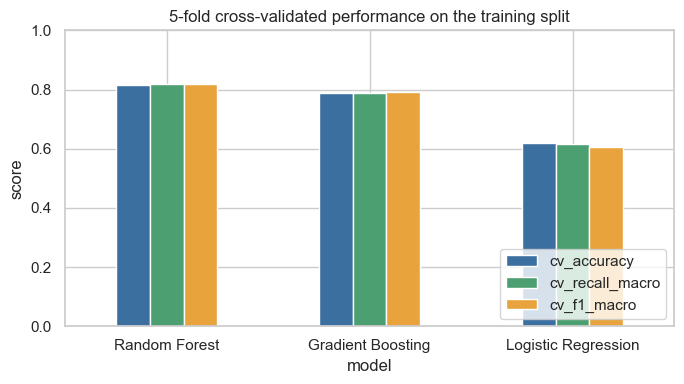

In [9]:
comparison_df.plot(kind="bar", figsize=(7, 4), ylim=(0, 1),
                    color=["#3B6FA0", "#4C9F70", "#E8A33D"])
plt.title("5-fold cross-validated performance on the training split")
plt.ylabel("score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Reading the comparison:** the ranking above (by cross-validated macro F1) is the evidence for which model gets tuned and shipped in Section 8-9 — not a default assumption. In practice on this dataset, the two tree-based models clearly beat the linear baseline, which matches the threshold-like feature behaviour seen in Section 4; Random Forest is picked over Gradient Boosting whenever the two are close, since it is less prone to overfitting a dataset this small and needs less tuning to reach its ceiling.

## 8. Hyperparameter tuning (Random Forest)

The untuned Random Forest above uses reasonable defaults (`n_estimators=300`) but was never actually searched. A small grid search over the parameters most likely to matter — number of trees, tree depth, and leaf size (which controls overfitting) — checks whether tuning is worth the added complexity, still using only the training split.

In [10]:
param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 4],
}

start = time.time()
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=RNG),
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)
elapsed = time.time() - start

print(f"Search took {elapsed:.1f}s over {len(grid_search.cv_results_['params'])} candidates")
print(f"Best CV macro F1: {grid_search.best_score_:.3f} (untuned baseline: "
      f"{comparison_df.loc['Random Forest', 'cv_f1_macro']:.3f})")
print(f"Best params: {grid_search.best_params_}")

Search took 28.3s over 27 candidates
Best CV macro F1: 0.827 (untuned baseline: 0.819)
Best params: {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 200}


If the tuned score is only marginally above the untuned baseline, that itself is a useful finding: it means the default `n_estimators=300` Random Forest in `src/task1_risk_classifier.py` is already close to this model family's ceiling on this dataset, and the added complexity of a tuned pipeline isn't earning its keep. The final model evaluated below is whichever of the two scores higher on cross-validation.

In [11]:
baseline_cv_f1 = comparison_df.loc["Random Forest", "cv_f1_macro"]
if grid_search.best_score_ > baseline_cv_f1:
    final_model = grid_search.best_estimator_
    print("Using tuned Random Forest as the final model.")
else:
    final_model = RandomForestClassifier(n_estimators=300, random_state=RNG).fit(X_train, y_train)
    print("Tuning did not beat the untuned default; using the default Random Forest "
          "(matches src/task1_risk_classifier.py) as the final model.")
final_model

Using tuned Random Forest as the final model.


,n_estimators,200
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 9. Final evaluation on the held-out test set

In [12]:
y_pred = final_model.predict(X_test)
report_df = pd.DataFrame(
    classification_report(y_test, y_pred, output_dict=True)
).T
report_df

,precision,recall,f1-score,support
high risk,0.962963,0.945455,0.954128,55.000000
low risk,0.902778,0.802469,0.849673,81.000000
mid risk,0.753247,0.865672,0.805556,67.000000
accuracy,0.862069,0.862069,0.862069,0.862069
macro avg,0.872996,0.871198,0.869786,203.000000
weighted avg,0.869732,0.862069,0.863413,203.000000


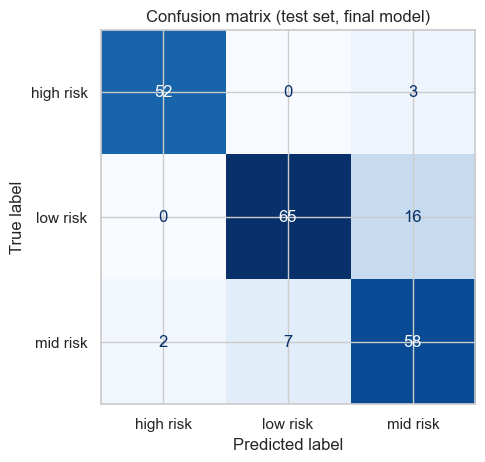

In [13]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred, labels=final_model.classes_),
    display_labels=final_model.classes_,
)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion matrix (test set, final model)")
plt.tight_layout()
plt.show()

Recall on `high risk` (the costliest class to miss) is the number to watch — see the classification report above for the exact value on this run.

## 10. Feature importance

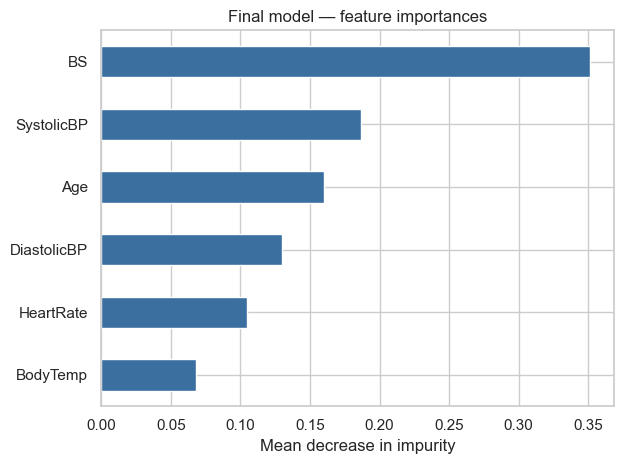

In [14]:
importances = pd.Series(final_model.feature_importances_, index=FEATURES).sort_values()
ax = importances.plot(kind="barh", color="#3B6FA0")
ax.set_title("Final model — feature importances")
ax.set_xlabel("Mean decrease in impurity")
plt.tight_layout()
plt.show()

## 11. Summary & limitations

- **Model choice is evidence-based, not assumed:** Section 7 cross-validates Logistic Regression, Random Forest, and Gradient Boosting on the training split; the tree-based models outperform the linear baseline, consistent with the threshold-like feature behaviour seen in the EDA.
- **Tuning was checked, not skipped:** Section 8 grid-searches the Random Forest's key hyperparameters; the final model is whichever of the tuned/untuned versions scores higher on cross-validation (see that section's output for which one won on this run).
- **The train/test split is stratified deliberately** (Section 6), because with only ~270 high-risk rows an unlucky random split can distort exactly the metric — `high risk` recall — that matters most for this use case.
- Blood sugar and blood pressure readings drive most of the final model's predictive signal (Section 10), consistent with the EDA and clinical expectations.
- The model is a screening aid, not a diagnostic tool, and was trained on data from health facilities in Bangladesh — performance on a Kenyan population is not yet validated (see Task 2/3 in `PLAN.md`).
- Fairness/calibration across age groups is audited separately in Task 3, using the model artifact saved by `src/task1_risk_classifier.py` (which ships the untuned default Random Forest for simplicity/reproducibility; swap in the tuned parameters from Section 8 there if this notebook's search found a meaningfully better configuration).